In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [29]:
df=pd.read_csv(r'C:\ML_PROJECT\child_labor_statistics - child_labor_statistics_20251214_123456.csv')


In [30]:
df.head()

,Country,Country_Code,Region,Year,Child_Labor_Rate_Percent,Estimated_Children_Millions,Gender,Age_Group
0,Afghanistan,AFG,Middle East and North Africa,2011,9.30,4.65,Total,7-14 years
1,Albania,ALB,Other,2010,5.50,2.75,Total,7-14 years
2,Algeria,DZA,Other,2013,7.50,3.75,Total,7-14 years
3,Argentina,ARG,Other,2012,5.03,2.51,Total,7-14 years
4,Armenia,ARM,Other,2010,9.90,4.95,Total,7-14 years


In [31]:
df.shape

(537, 8)

In [32]:
df.tail()

,Country,Country_Code,Region,Year,Child_Labor_Rate_Percent,Estimated_Children_Millions,Gender,Age_Group
532,World,WORLD,Global,2008,6.08,92.0,Girls,5-17 years
533,World,WORLD,Global,2000,16.00,246.0,Total,5-17 years
534,World,WORLD,Global,2000,11.12,171.0,Total,5-17 years
535,World,WORLD,Global,2000,9.43,145.0,Boys,5-17 years
536,World,WORLD,Global,2000,6.57,101.0,Girls,5-17 years


In [33]:
df.describe()

,Year,Child_Labor_Rate_Percent,Estimated_Children_Millions
count,537.000000,537.000000,537.000000
mean,2016.109870,18.474376,12.571676
std,5.640095,15.275823,25.765602
min,2000.000000,0.400000,0.200000
25%,2011.000000,5.560000,2.100000
50%,2014.000000,13.200000,4.650000
75%,2023.000000,28.500000,12.800000
max,2024.000000,65.350000,246.000000


In [34]:
df.isnull().sum().sum()

np.int64(0)

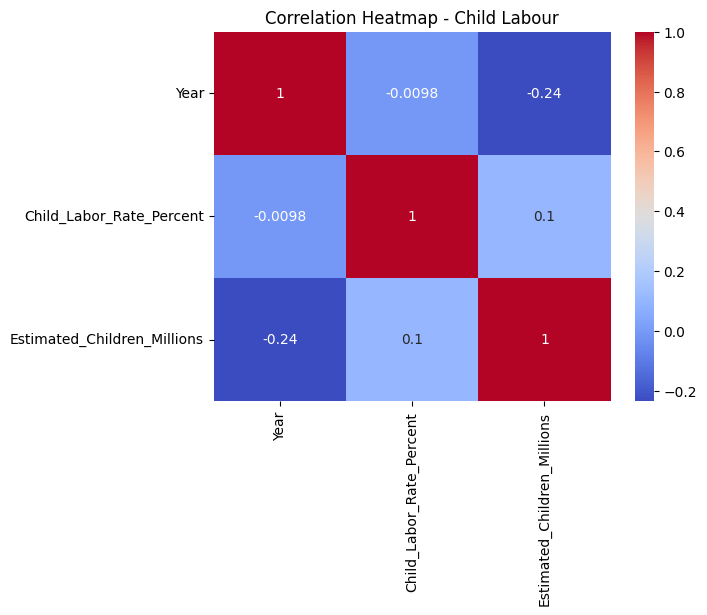

In [35]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - Child Labour")
mtb.show()


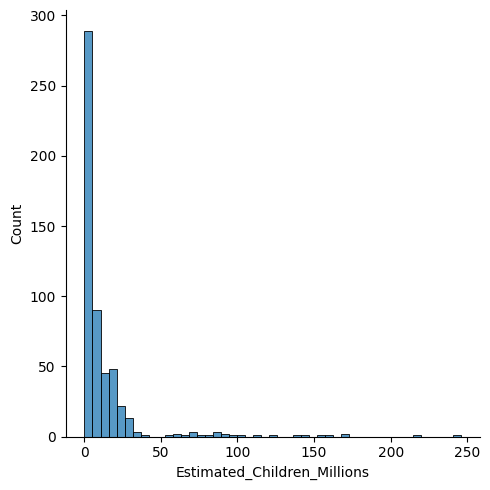

In [36]:
sns.displot(df["Estimated_Children_Millions"])

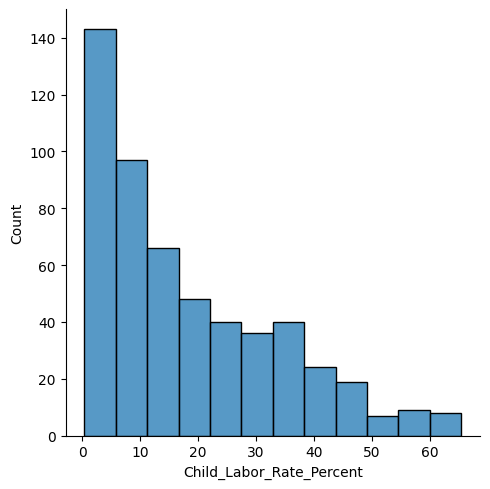

In [37]:
sns.displot(df["Child_Labor_Rate_Percent"])


In [38]:
X = df.drop("Child_Labor_Rate_Percent", axis=1)
y = df["Child_Labor_Rate_Percent"]


In [39]:
X = pd.get_dummies(X, drop_first=True)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_test_scaled)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse:", mse)
print("r2 Score:", r2)

mse: 48.852992177151854
r2 Score: 0.7666632503939754


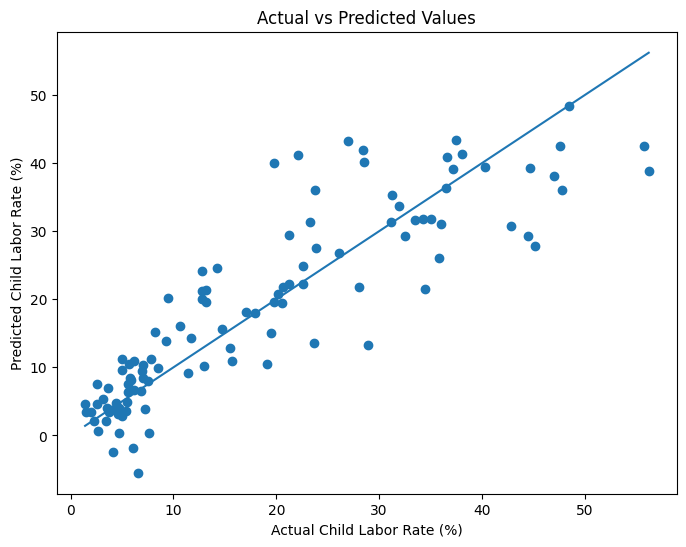

In [59]:
mtb.figure(figsize=(8,6))
mtb.scatter(y_test, y_pred)
mtb.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
mtb.xlabel("Actual Child Labor Rate (%)")
mtb.ylabel("Predicted Child Labor Rate (%)")
mtb.title("Actual vs Predicted Values")
mtb.show()


***Most points lie close to the diagonal, showing good prediction accuracy***